In [24]:
!pip install seaborn

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import seaborn as sns
import time

device = torch.device("a" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [28]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

classes = trainset.classes

100%|███████████████████████████████████████████████████████████████████████████████| 170M/170M [00:46<00:00, 3.70MB/s]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8666667..0.81960785].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.70980394].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.88235295].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..0.8980392].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..0.7176471].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.654902..0.94509804].


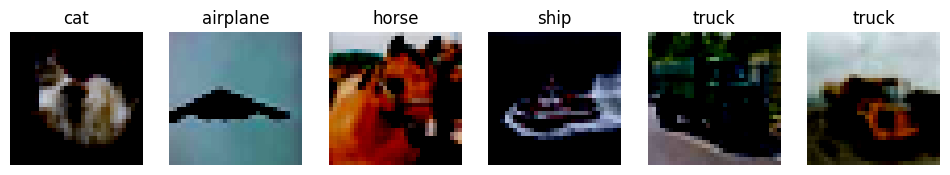

In [29]:
images, labels = next(iter(trainloader))

fig, axes = plt.subplots(1,6, figsize=(12,3))
for i in range(6):
    axes[i].imshow(np.transpose(images[i], (1,2,0)))
    axes[i].set_title(classes[labels[i]])
    axes[i].axis('off')
plt.show()

In [30]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super(SimpleCNN,self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(128*4*4,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,10)
        )

    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x
     

In [44]:
def train_model(model, epochs=10):

    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses=[]
    val_losses=[]

    start=time.time()

    for epoch in range(epochs):

        model.train()
        running_loss=0

        for images,labels in trainloader:

            images,labels = images.to(device),labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs,labels)

            loss.backward()
            optimizer.step()

            running_loss+=loss.item()

        train_losses.append(running_loss/len(trainloader))

        print(f"Epoch {epoch+1}, Loss {train_losses[-1]:.4f}")

    total_time=time.time()-start
    return train_losses,total_time

In [46]:
simple_model = SimpleCNN()

losses_simple, time_simple = train_model(simple_model,10)

Epoch 1, Loss 1.3711
Epoch 2, Loss 1.0163
Epoch 3, Loss 0.8705
Epoch 4, Loss 0.7773
Epoch 5, Loss 0.7084
Epoch 6, Loss 0.6477
Epoch 7, Loss 0.5983
Epoch 8, Loss 0.5578
Epoch 9, Loss 0.5119
Epoch 10, Loss 0.4882


Accuracy: 77.15


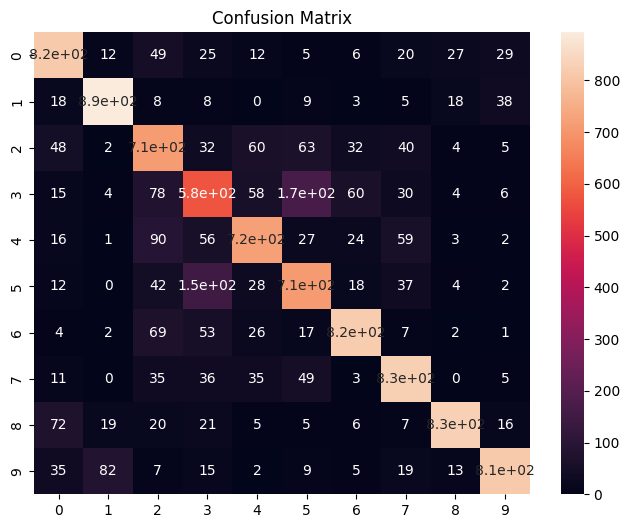

In [40]:
def evaluate_model(model):

    model.eval()

    correct=0
    total=0
    all_preds=[]
    all_labels=[]

    with torch.no_grad():

        for images,labels in testloader:

            images,labels=images.to(device),labels.to(device)

            outputs=model(images)

            _,predicted=torch.max(outputs,1)

            correct+=(predicted==labels).sum().item()
            total+=labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc=100*correct/total
    print("Accuracy:",acc)

    cm = confusion_matrix(all_labels,all_preds)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm,annot=True)
    plt.title("Confusion Matrix")
    plt.show()
    return acc

    
acc_simple = evaluate_model(simple_model)


In [50]:
transfer_model = models.resnet18(pretrained=True)

for param in transfer_model.parameters():
    param.requires_grad = False

transfer_model.fc = nn.Linear(512,10)

transfer_model = transfer_model.to(device)

Epoch 1, Loss 1.7342
Epoch 2, Loss 1.5976
Epoch 3, Loss 1.5845
Epoch 4, Loss 1.5717
Epoch 5, Loss 1.5702
Accuracy: 44.81


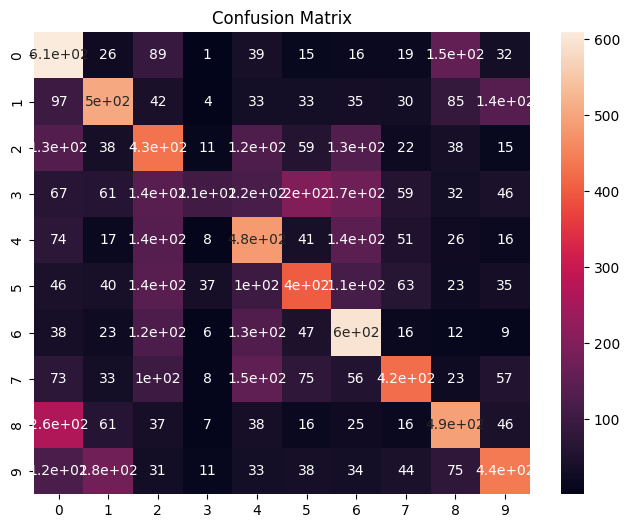

In [48]:
losses_transfer, time_transfer = train_model(transfer_model,5)
acc_transfer = evaluate_model(transfer_model)